In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### Data Loading
data=pd.read_csv("Default Dataset.csv", header=None)
data.head()

,0,1
0,94.250,241.95
1,99.355,232.03
2,100.760,221.66
3,104.500,241.53
4,107.020,213.01


In [3]:

### Renaming Columns
data.columns=pd.Index(['x', 'y'])
data.head()

,x,y
0,94.250,241.95
1,99.355,232.03
2,100.760,221.66
3,104.500,241.53
4,107.020,213.01


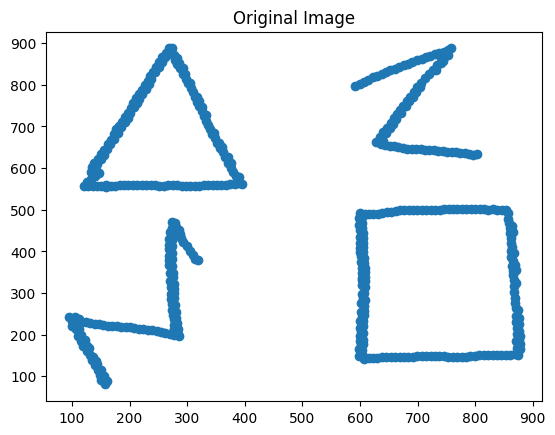

In [4]:

### Vizualization (original image)
plt.scatter(data['x'], data['y']); 
plt.title('Original Image'); 

In [5]:

# Data Cleaning 

# All values in both x and y axis are between 0 and 1000. In order to make a 1000x1000 matrix the steps I will follow are
# as follows:
# 1) Round the data to the nearest integer. Drop the duplicate rows.
# 2) Discretize the data. Create a 1000x1000 matrix of zeros.
# 3) The entries of the transformed data are a tuple (x, y) where 0<x,y<1000, look at each entry of the dataset, go to 
#    the (x, y)th entry of the matrix and replace 0 by 1.
# 5) Sparse matrix will be created.


data_trans=data.round(0).drop_duplicates().astype(dtype=int)
data_trans.shape

(485, 2)

In [6]:

### Creating Sparse Representation
data_matrix=np.zeros(shape=(1000, 1000))
for idx, coordinate in data_trans.iterrows():
    data_matrix[coordinate['x'], coordinate['y']]=1


In [7]:

### Creating a function that converts data matrix to x,y pairs data
def matrix_to_df(matrix):
    x_max, y_max=matrix.shape
    df_data=[]
    for i in range(x_max):
        for j in range(y_max):
            if (matrix[i, j]==1):
                df_data.append([i, j])
    return pd.DataFrame(df_data, columns=['x', 'y'])

### Creating a function that plots the scatter plot with matrix as input
def plot_scattter_matrix(matrix):
    df=matrix_to_df(matrix)
    plt.scatter(df['x'], df['y'])

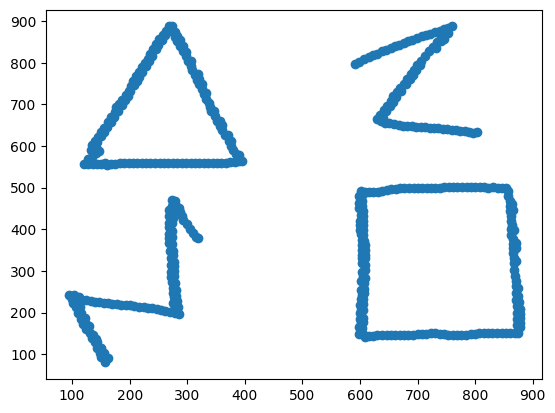

In [8]:
### Checking if conversion is working correctly
plot_scattter_matrix(data_matrix)

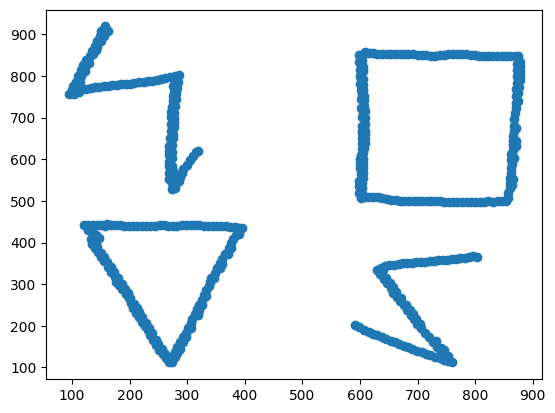

In [9]:
trans_flip_op=np.zeros(shape=(1000, 1000), dtype=int)
for i in range(1000):
    trans_flip_op[999-i, i]=1


trans_filp_res=np.matmul(data_matrix, trans_flip_op)
plot_scattter_matrix(trans_filp_res)

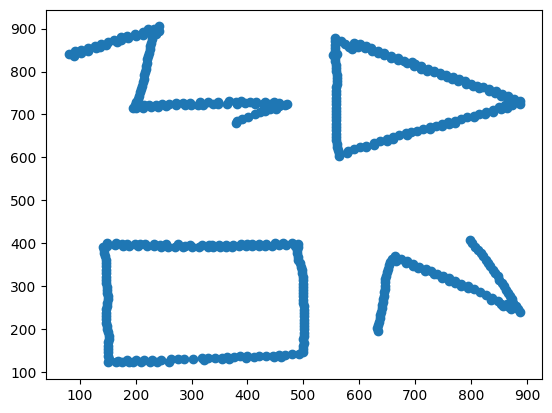

In [10]:
plot_scattter_matrix(data_matrix.T @ trans_flip_op)

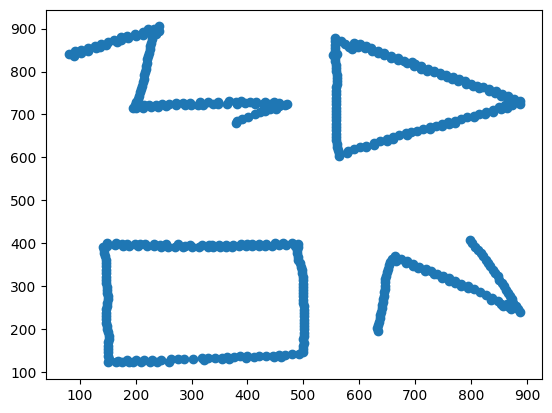

In [13]:
plot_scattter_matrix(np.rot90(data_matrix, k=3))